<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning & Deep Learning</b></center>

<center><b><h1>Lab - 5</b></center>    
<pre>    

# SVR

# Importing the libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read World bank CSV

In [2]:
df=pd.read_csv("WorldBank.csv")

In [3]:
df

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,India,IND,Export value index (2000 = 100),TX.VAL.MRCH.XD.WD,NaN,NaN,NaN,NaN,NaN,NaN,...,7.147485e+02,7.004085e+02,7.429281e+02,7.614417e+02,6.322694e+02,6.242250e+02,7.061028e+02,7.663608e+02,NaN,NaN
1,India,IND,Insurance and financial services (% of commerc...,TX.VAL.INSF.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,...,6.403614e+00,5.246771e+00,5.729495e+00,5.060904e+00,4.706801e+00,4.471147e+00,3.760466e+00,3.921611e+00,3.438072e+00,NaN
2,India,IND,"Merchandise imports by the reporting economy, ...",TM.VAL.MRCH.RS.ZS,4.983551,6.488050e+00,1.012461e+01,9.451370e+00,1.052948e+01,1.089112e+01,...,7.550664e-01,2.738416e-01,4.409538e-01,1.514439e+00,2.228351e+00,2.270593e+00,1.770314e+00,5.354193e-01,NaN,NaN
3,India,IND,Food imports (% of merchandise imports),TM.VAL.FOOD.ZS.UN,NaN,NaN,1.708001e+01,1.519791e+01,1.686304e+01,2.200813e+01,...,3.741041e+00,4.048246e+00,3.895215e+00,4.458509e+00,5.758038e+00,6.505293e+00,6.137617e+00,4.156488e+00,4.248261e+00,NaN
4,India,IND,Share of tariff lines with international peaks...,TM.TAX.MRCH.IP.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,8.434346e+00,8.641136e+00,8.576307e+00,NaN,5.802677e+00,7.707811e+00,8.288774e+00,9.111423e+00,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,India,IND,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,2.002065e+00,1.312934e+00,1.516276e+00,1.695659e+00,2.092116e+00,1.937363e+00,1.506588e+00,1.552336e+00,1.760283e+00,NaN
1436,India,IND,"Net capital account (BoP, current US$)",BN.TRF.KOGT.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,6.791581e+07,-5.972328e+08,9.618297e+08,-7.433364e+07,3.706943e+07,1.368359e+08,3.731153e+07,-1.231007e+08,-1.155591e+09,NaN
1437,India,IND,"Travel services (% of service imports, BoP)",BM.GSR.TRVL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,1.761773e+01,1.544257e+01,1.475397e+01,1.799216e+01,1.795378e+01,1.707263e+01,1.686302e+01,1.716750e+01,1.755462e+01,NaN
1438,India,IND,Cereal production (metric tons),AG.PRD.CREL.MT,NaN,8.737650e+07,8.725755e+07,9.037301e+07,9.370600e+07,7.969950e+07,...,2.878600e+08,2.932900e+08,2.949095e+08,2.960100e+08,2.843330e+08,2.978500e+08,3.136100e+08,NaN,NaN,NaN


# Perform conditional selection to find - Population ages 15-64 (% of total population)

In [4]:
data=df[df['Indicator Name'] == "Population ages 15-64 (% of total population)"]
data

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
9,India,IND,Population ages 15-64 (% of total population),SP.POP.1564.TO.ZS,56.49748,56.177532,55.807455,55.461664,55.248939,55.211351,...,64.429404,64.805519,65.208489,65.59598,65.944164,66.274262,66.538187,66.766743,67.003811,NaN


# Divide the data into input and output

In [6]:
x=np.arange(1960,2020).reshape(-1,1)
x

array([[1960],
       [1961],
       [1962],
       [1963],
       [1964],
       [1965],
       [1966],
       [1967],
       [1968],
       [1969],
       [1970],
       [1971],
       [1972],
       [1973],
       [1974],
       [1975],
       [1976],
       [1977],
       [1978],
       [1979],
       [1980],
       [1981],
       [1982],
       [1983],
       [1984],
       [1985],
       [1986],
       [1987],
       [1988],
       [1989],
       [1990],
       [1991],
       [1992],
       [1993],
       [1994],
       [1995],
       [1996],
       [1997],
       [1998],
       [1999],
       [2000],
       [2001],
       [2002],
       [2003],
       [2004],
       [2005],
       [2006],
       [2007],
       [2008],
       [2009],
       [2010],
       [2011],
       [2012],
       [2013],
       [2014],
       [2015],
       [2016],
       [2017],
       [2018],
       [2019]])

In [7]:
y=data.values[0][4:-1:].reshape(-1,1)
y

array([[56.49748004],
       [56.17753236],
       [55.80745463],
       [55.46166361],
       [55.24893881],
       [55.21135053],
       [55.09090078],
       [55.15534672],
       [55.34507283],
       [55.57014408],
       [55.78194745],
       [55.85676846],
       [55.95268174],
       [56.07247186],
       [56.23447551],
       [56.44405309],
       [56.49722595],
       [56.62068516],
       [56.78900152],
       [56.9691436],
       [57.1425581],
       [57.18105454],
       [57.22630775],
       [57.28875038],
       [57.39054366],
       [57.54142108],
       [57.55350984],
       [57.6545119],
       [57.81875323],
       [58.01501187],
       [58.22990246],
       [58.37403848],
       [58.5472698],
       [58.75605047],
       [59.012126],
       [59.31657719],
       [59.56507329],
       [59.8572303],
       [60.18600058],
       [60.53971518],
       [60.90862046],
       [61.18898716],
       [61.4993847],
       [61.83084479],
       [62.173897],
       [62.52276485]

In [ ]:
pl

array([[56.49748004],
       [56.17753236],
       [55.80745463],
       [55.46166361],
       [55.24893881],
       [55.21135053],
       [55.09090078],
       [55.15534672],
       [55.34507283],
       [55.57014408],
       [55.78194745],
       [55.85676846],
       [55.95268174],
       [56.07247186],
       [56.23447551],
       [56.44405309],
       [56.49722595],
       [56.62068516],
       [56.78900152],
       [56.9691436],
       [57.1425581],
       [57.18105454],
       [57.22630775],
       [57.28875038],
       [57.39054366],
       [57.54142108],
       [57.55350984],
       [57.6545119],
       [57.81875323],
       [58.01501187],
       [58.22990246],
       [58.37403848],
       [58.5472698],
       [58.75605047],
       [59.012126],
       [59.31657719],
       [59.56507329],
       [59.8572303],
       [60.18600058],
       [60.53971518],
       [60.90862046],
       [61.18898716],
       [61.4993847],
       [61.83084479],
       [62.173897],
       [62.52276485]

# Plot scatter plot of Population ages 15-64 (% of total population)

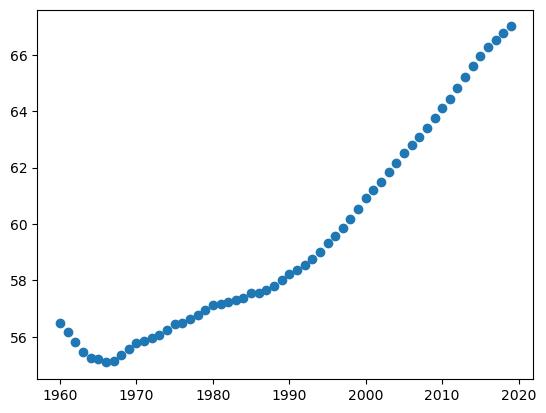

In [10]:
plt.scatter(x,y)


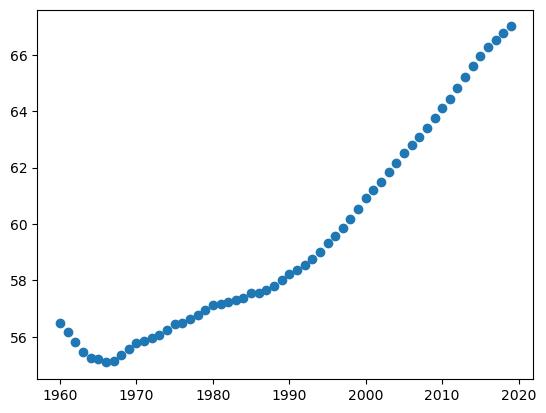

# Feature Scaling (Mandatory for SVR)**
SVR is highly sensitive to the range of data points. If we don't scale (normalize) the data, the model will fail to find the correct hyperplane.

In [11]:
from sklearn.preprocessing import StandardScaler

In [12]:
sc_x=StandardScaler()
sc_y=StandardScaler()

x_scale=sc_x.fit_transform(x)
y_scale=sc_y.fit_transform(y)

print("Scale completed")

Scale completed


# Splitting the dataset into the Training set and Test set

In [13]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x_scale,y_scale,test_size=0.2,random_state=42)

In [14]:
x_train

array([[ 0.08661457],
       [-1.53019075],
       [ 1.29921857],
       [-0.72178809],
       [-1.24147552],
       [-1.35696161],
       [ 0.606302  ],
       [-1.47244771],
       [ 0.77953114],
       [-0.606302  ],
       [ 0.25984371],
       [ 1.64567685],
       [-0.25984371],
       [ 1.53019075],
       [-0.83727419],
       [-0.14435762],
       [-1.18373247],
       [ 0.02887152],
       [-0.20210067],
       [-0.77953114],
       [-0.31758676],
       [ 1.47244771],
       [-1.06824638],
       [ 0.14435762],
       [ 1.35696161],
       [ 0.66404504],
       [ 0.43307286],
       [-0.02887152],
       [ 0.83727419],
       [-1.64567685],
       [-0.4908159 ],
       [-1.5879338 ],
       [ 1.01050333],
       [ 0.54855895],
       [ 0.31758676],
       [-0.37532981],
       [ 1.12598942],
       [-1.12598942],
       [-0.43307286],
       [-0.66404504],
       [ 1.7034199 ],
       [-0.54855895],
       [-1.29921857],
       [ 0.72178809],
       [-0.89501723],
       [-0

# Fitting SVR on 3 Different Kernel on dataset

In [15]:
from sklearn.svm import SVR

In [16]:
model_rbf=SVR()

In [19]:
model_rbf.fit(x_train,y_train.ravel())

SVR()

C:\Users\HP\AppData\Local\Temp\ipykernel_1000\2836442725.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x_grid=np.arange(min(x_test),max(x_test),0.01)


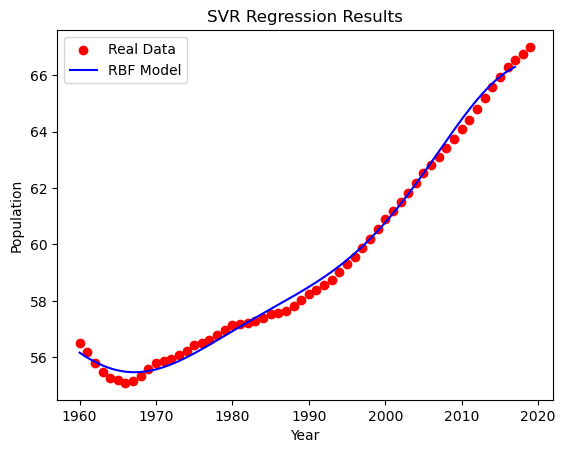

In [24]:
x_grid=np.arange(min(x_test),max(x_test),0.01)
x_grid=x_grid.reshape(len(x_grid),1)

plt.scatter(x,y,color="red",label="Real Data")

plt.plot(sc_x.inverse_transform(x_grid), sc_y.inverse_transform(model_rbf.predict(x_grid).reshape(-1,1)), color="blue", label="RBF Model")

plt.title("SVR Regression Results")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend()
plt.show()

# Predict the x_test using 3 Kernel

In [21]:
model_rbf.score(x_train,y_train)

0.9953867997446317

In [22]:
model_rbf.score(x_test,y_test)

0.9963995902170167

In [25]:
y_pridict_rbf=model_rbf.predict(x_test)

In [26]:
y_test

array([[-0.81106651],
       [-1.16669445],
       [ 0.03715435],
       [ 0.85498626],
       [-0.92858561],
       [ 1.7047616 ],
       [-0.18654872],
       [ 1.10010786],
       [-0.9617088 ],
       [ 1.96529151],
       [ 0.93397554],
       [ 1.29337818]])

array([57.73445326, 59.30206118, 64.8451716 , 57.99812952, 55.96479236,
       56.12587167, 59.06485884, 64.91876466, 60.76906052, 57.24445561,
       55.93360816, 55.89821768, 58.29641078, 61.1088798 , 58.84682535,
       61.81299688, 63.81278461, 55.81527994])

# Visualising the  results

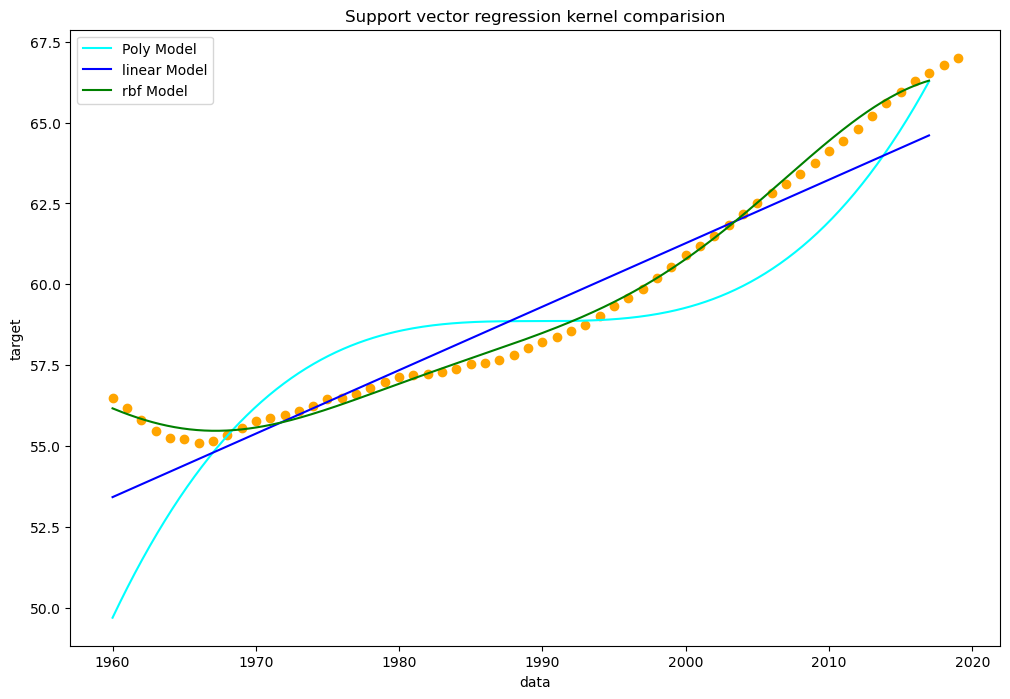

In [28]:
svr_lin=SVR(kernel="linear")
svr_poly=SVR(kernel="poly",degree=3)
svr_rbf=SVR(kernel="rbf")

svr_rbf.fit(x_train,y_train.ravel())
svr_poly.fit(x_train,y_train.ravel())
svr_lin.fit(x_train,y_train.ravel())

plt.figure(figsize=[12,8])
plt.scatter(x,y,color="orange")
plt.plot(sc_x.inverse_transform(x_grid), sc_y.inverse_transform(svr_poly.predict(x_grid).reshape(-1,1)), color="cyan", label="Poly Model")
plt.plot(sc_x.inverse_transform(x_grid), sc_y.inverse_transform(svr_lin.predict(x_grid).reshape(-1,1)), color="blue", label="linear Model")
plt.plot(sc_x.inverse_transform(x_grid), sc_y.inverse_transform(svr_rbf.predict(x_grid).reshape(-1,1)), color="green", label="rbf Model")


plt.title("Support vector regression kernel comparision")
plt.xlabel("data")
plt.ylabel("target")
plt.legend()
plt.show()

### **Student Activity : Prediction**
**Task:** Predict the value for the Year **2025** (or value 6.5 in the demo data). 
Remember: You must transform the input before predicting, and inverse transform the output.

In [30]:
value_prodict=[[2025]]

val_saled=sc_x.transform(value_prodict)

pred_scalre=svr_lin.predict(val_saled)

pred_final=sc_y.inverse_transform(pred_scalre.reshape(-1,1))

print(f"The predicted value for input 2025 is{pred_final}")

The predicted value for input 2025 is[[66.17676668]]


In [31]:
value_prodict=[[2025]]

val_saled=sc_x.transform(value_prodict)

pred_scalre=svr_poly.predict(val_saled)

pred_final=sc_y.inverse_transform(pred_scalre.reshape(-1,1))

print(f"The predicted value for input 2025 is{pred_final}")

The predicted value for input 2025 is[[74.84084919]]


In [32]:
value_prodict=[[2025]]

val_saled=sc_x.transform(value_prodict)

pred_scalre=svr_rbf.predict(val_saled)

pred_final=sc_y.inverse_transform(pred_scalre.reshape(-1,1))

print(f"The predicted value for input 2025 is{pred_final}")

The predicted value for input 2025 is[[65.82072271]]
